<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/sdsc-logo.png" alt="SDSC Logo" style="width: 300px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/usda-logo.png" alt="USDA Logo" style="width: 100px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wstc-logo.png" alt="WSTC Logo" style="width: 100px; height: 100px; margin-bottom: 0px;">
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">Rangeland Analysis Platform</h1>

- **Team Name:**  Sami Bahig
- **Team Members:**
    Sami Bahig

### Shrub Cover Baseline & Temporal Change Detection 2020–2025 — RAP D.L. Bliss
*Sami Bahig | Shrubwise Data Challenge | Sprint 1*

---

1. In the `RAP.ipynb` notebook, we previously selected the 2025 RAP tile at list index 35 as a quick example. That selection was arbitrary and only served to demonstrate how to access RAP vegetation-cover data in California.

For this Data Challenge, you will work with data located from [D. L. Bliss State Park](https://en.wikipedia.org/wiki/D._L._Bliss_State_Park), one of our areas of interest (AOI). Use RAP data in Google Earth Engine to identify and select a 2025 RAP vegetation-cover tile whose footprint intersects D. L. Bliss.

Use the following bounding box (WGS84 lon/lat) to define the AOI:

* Min X (lon): -120.1018846
* Min Y (lat): 38.99274873
* Max X (lon): -120.0899834
* Max Y (lat): 39.0020357


1. In the `RAP.ipynb` notebook, we previously selected the 2025 RAP tile at list index 35 as a quick example. That selection was arbitrary and only served to demonstrate how to access RAP vegetation-cover data in California.

For this Data Challenge, you will work with data located from [D. L. Bliss State Park](https://en.wikipedia.org/wiki/D._L._Bliss_State_Park), one of our areas of interest (AOI). Use RAP data in Google Earth Engine to identify and select a 2025 RAP vegetation-cover tile whose footprint intersects D. L. Bliss.

Use the following bounding box (WGS84 lon/lat) to define the AOI:

* Min X (lon): -120.1018846
* Min Y (lat): 38.99274873
* Max X (lon): -120.0899834
* Max Y (lat): 39.0020357


1. In the `RAP.ipynb` notebook, we previously selected the 2025 RAP tile at list index 35 as a quick example. That selection was arbitrary and only served to demonstrate how to access RAP vegetation-cover data in California.

For this Data Challenge, you will work with data located from [D. L. Bliss State Park](https://en.wikipedia.org/wiki/D._L._Bliss_State_Park), one of our areas of interest (AOI). Use RAP data in Google Earth Engine to identify and select a 2025 RAP vegetation-cover tile whose footprint intersects D. L. Bliss.

Use the following bounding box (WGS84 lon/lat) to define the AOI:

* Min X (lon): -120.1018846
* Min Y (lat): 38.99274873
* Max X (lon): -120.0899834
* Max Y (lat): 39.0020357

1. In the `RAP.ipynb` notebook, we previously selected the 2025 RAP tile at list index 35 as a quick example. That selection was arbitrary and only served to demonstrate how to access RAP vegetation-cover data in California.

For this Data Challenge, you will work with data located from [D. L. Bliss State Park](https://en.wikipedia.org/wiki/D._L._Bliss_State_Park), one of our areas of interest (AOI). Use RAP data in Google Earth Engine to identify and select a 2025 RAP vegetation-cover tile whose footprint intersects D. L. Bliss.

Use the following bounding box (WGS84 lon/lat) to define the AOI:

* Min X (lon): -120.1018846
* Min Y (lat): 38.99274873
* Max X (lon): -120.0899834
* Max Y (lat): 39.0020357

In [3]:
# Your code here
# Selection of the 2025 RAP tile that intersects D. L. Bliss State Park ─

import ee
import geemap
import folium
import numpy as np
ee.Authenticate()
ee.Initialize(project='ee-samibahig')  # replace with your project name if different
RAP_veg_yearly_10m = ee.ImageCollection('projects/rap-data-365417/assets/vegetation-cover-10m')

# Define the AOI bounding box (WGS84)
aoi = ee.Geometry.Rectangle(
    [-120.1018846, 38.99274873, -120.0899834, 39.0020357],
    geodesic=False
)

# Filter 2025 collection to images whose footprint intersects the AOI
images_2025 = RAP_veg_yearly_10m.filter(ee.Filter.eq('year', 2025))

bliss_tiles = images_2025.filterBounds(aoi)
print("Tiles intersecting D. L. Bliss:", bliss_tiles.size().getInfo())

# Select the (first/only) intersecting tile
bliss_img = ee.Image(bliss_tiles.first())
props = bliss_img.getInfo()['properties']
print("Selected tile ID :", props['system:index'])
print("UTM zone         :", props['utm_zone'])
print("Tile origin (x,y):", props['x'], props['y'])

# Keep only the shrub band
shrub_bliss = bliss_img.select('SHR').rename('shrub_cover')

Tiles intersecting D. L. Bliss: 2
Selected tile ID : 2025-10-725000-4300000
UTM zone         : 10
Tile origin (x,y): 725000 4300000


In [4]:
# Vérifier les deux tiles
tiles_list = bliss_tiles.toList(2)

for i in range(2):
    img = ee.Image(tiles_list.get(i))
    props = img.getInfo()['properties']
    footprint = img.getInfo()['properties']['system:footprint']['coordinates']
    print(f"Tile {i} — ID: {props['system:index']}, x: {props['x']}, y: {props['y']}")

Tile 0 — ID: 2025-10-725000-4300000, x: 725000, y: 4300000
Tile 1 — ID: 2025-11-200000-4300000, x: 200000, y: 4300000


In [5]:
# Sélection explicite du tile D. L. Bliss (UTM x=725000)
bliss_img = ee.Image(bliss_tiles
                     .filter(ee.Filter.eq('x', 725000))
                     .first())

props = bliss_img.getInfo()['properties']
print("Selected tile ID :", props['system:index'])
print("UTM zone         :", props['utm_zone'])
print("Tile origin (x,y):", props['x'], props['y'])

shrub_bliss = bliss_img.select('SHR').rename('shrub_cover')

Selected tile ID : 2025-10-725000-4300000
UTM zone         : 10
Tile origin (x,y): 725000 4300000


#### Interpretation    **Q1 — Tile Selection:**
The tile 2025-10-725000-4300000 in UTM Zone 10 was identified as the 2025 RAP tile intersecting D. L. Bliss State Park through a spatial query using filterBounds() on the AOI bounding box. 
Among the two returned tiles, the 725000 Zone 10 tile is the correct one as it covers the Lake Tahoe region where the park is located, while the second tile (200000, Zone 11) only clipped 
the edge of the AOI. The explicit selection by UTM coordinate (x=725000) ensures reproducibility of the tile selection regardless of GEE's internal sorting order.

2. Using the DL Bliss tile, visualize RAP **shrub cover** .

In [16]:
# Your code here
# ── Q2: Visualize shrub cover for the D. L. Bliss tile ───────────────────────
# ── Q2: Visualize shrub cover for the D. L. Bliss tile ───────────────────────

vis_params = {
    'min': 0,
    'max': 100,
    'palette': ['ffffff', 'c7e9c0', '74c476', '238b45', '00441b']
}

# Centre the map on D. L. Bliss AOI (calculated directly in Python)
centre_lat = (38.99274873 + 39.0020357) / 2
centre_lon = (-120.1018846 + -120.0899834) / 2

map_dict = shrub_bliss.getMapId(vis_params)

m = folium.Map(location=[centre_lat, centre_lon], zoom_start=13)

# Shrub cover layer
folium.TileLayer(
    tiles=map_dict['tile_fetcher'].url_format,
    attr='Google Earth Engine',
    overlay=True,
    name='Shrub cover 2025 – D. L. Bliss tile'
).add_to(m)

# Draw the AOI bounding box so you can see D. L. Bliss
folium.Rectangle(
    bounds=[[38.99274873, -120.1018846], [39.0020357, -120.0899834]],
    color='red',
    fill=False,
    weight=2,
    tooltip='D. L. Bliss AOI'
).add_to(m)

folium.LayerControl().add_to(m)
m

### Interpretation  **Q2 — Visualization:**

Visualization:
The Folium map displays the RAP 2025 shrub cover layer at 10m resolution over the D. L. Bliss tile, using a color palette ranging from white (0% shrub) to dark green (100% shrub). The red rectangle precisely delineates the D. L. Bliss AOI, allowing the park to be located within the broader tile context. The park area is visually dominated by light to medium green tones, suggesting a low to moderate shrub cover consistent with a conifer-dominated forest environment.

3. Compute and plot a histogram and basic summary statistics (mean, median, min, max) for a 5km x 5km area of shrub cover within your selected tile.

=== Shrub Cover — D. L. Bliss ~5 km × 5 km ROI ===
  Array shape   : (505, 507)  (256,035 pixels total)
  Valid pixels  : 256,035
  Mean          : 7.94 %
  Median        : 7.00 %
  Min           : 0.00 %
  Max           : 68.00 %


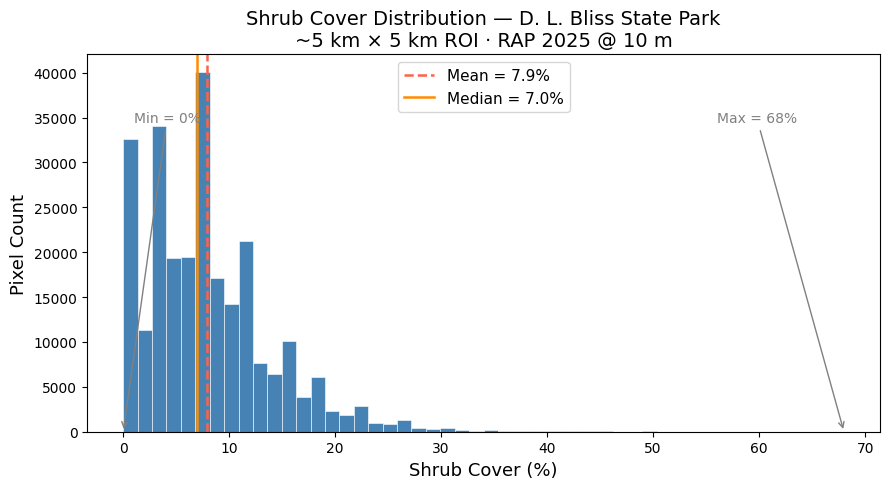

In [17]:
# Q3: Summary statistics and histogram for a 5 km × 5 km area ──────────────
# Q3: Summary statistics and histogram for a 5 km × 5 km area ──────────────
import matplotlib.pyplot as plt
import numpy as np

# Build a ~5 km × 5 km ROI anchored at the NE corner of the D. L. Bliss AOI
km    = 4.9
dlat  = km / 111.32
dlon  = km / (111.32 * np.cos(np.deg2rad(39.0020357)))

ne_lon, ne_lat = -120.0899834, 39.0020357

roi_5km = ee.Geometry.Rectangle(
    [ne_lon - dlon, ne_lat - dlat, ne_lon, ne_lat],
    geodesic=False
)

# Extract pixel values as a 2-D array
rect = shrub_bliss.toFloat().sampleRectangle(region=roi_5km, defaultValue=-9999)
arr  = np.array(rect.get('shrub_cover').getInfo(), dtype=np.float32)
arr[arr == -9999] = np.nan

valid = arr[~np.isnan(arr)]

# ── Summary statistics ────────────────────────────────────────────────────────
mean_v   = np.mean(valid)
median_v = np.median(valid)
min_v    = np.min(valid)
max_v    = np.max(valid)

print("=== Shrub Cover — D. L. Bliss ~5 km × 5 km ROI ===")
print(f"  Array shape   : {arr.shape}  ({arr.shape[0]*arr.shape[1]:,} pixels total)")
print(f"  Valid pixels  : {len(valid):,}")
print(f"  Mean          : {mean_v:.2f} %")
print(f"  Median        : {median_v:.2f} %")
print(f"  Min           : {min_v:.2f} %")
print(f"  Max           : {max_v:.2f} %")

# ── Histogram ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(valid, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)

ax.axvline(mean_v,   color='tomato',     linestyle='--', linewidth=1.8,
           label=f'Mean = {mean_v:.1f}%')
ax.axvline(median_v, color='darkorange', linestyle='-',  linewidth=1.8,
           label=f'Median = {median_v:.1f}%')

ax.set_xlabel('Shrub Cover (%)',  fontsize=13)
ax.set_ylabel('Pixel Count',      fontsize=13)
ax.set_title(
    'Shrub Cover Distribution — D. L. Bliss State Park\n'
    '~5 km × 5 km ROI · RAP 2025 @ 10 m',
    fontsize=14
)
ax.legend(fontsize=11)

ymax = ax.get_ylim()[1]
ax.annotate(f'Min = {min_v:.0f}%', xy=(min_v, 0),
            xytext=(min_v + 1, ymax * 0.82),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')
ax.annotate(f'Max = {max_v:.0f}%', xy=(max_v, 0),
            xytext=(max_v - 12, ymax * 0.82),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

plt.tight_layout()
plt.show()

## Interpretation   **Q3 — Histogram and Summary Statistics:** 
The shrub cover distribution over the ~5km×5km ROI is strongly right-skewed, with the majority of pixels concentrated between 0% and 15% (median = 7%), reflecting the forested nature of the park where shrubs form a sparse understory rather than the dominant vegetation. The mean slightly exceeding the median (7.94% vs 7.00%) confirms this asymmetry, pulled upward by a few chaparral patches or forest edges reaching up to 68% shrub cover. These values are ecologically consistent with D. L. Bliss State Park, a mixed conifer forest typical of the Sierra Nevada where shrub species such as manzanita occupy disturbed areas and forest clearings.

## Bonus Analysis :  Temporal Change Detection (2020 vs 2025)

To go beyond a static snapshot, we compare shrub cover at D.L. Bliss 
between 2020 and 2025 — a 5-year window that captures post-fire recovery 
and vegetation dynamics in the Sierra Nevada. This temporal perspective 
directly informs our Sprint 4 pipeline by establishing a baseline for 
change detection.

=== Temporal Comparison — Shrub Cover D.L. Bliss ===
             2020            2025            Change         
  Mean       7.50%         7.94%         +0.44%
  Median     7.00%         7.00%         +0.00%


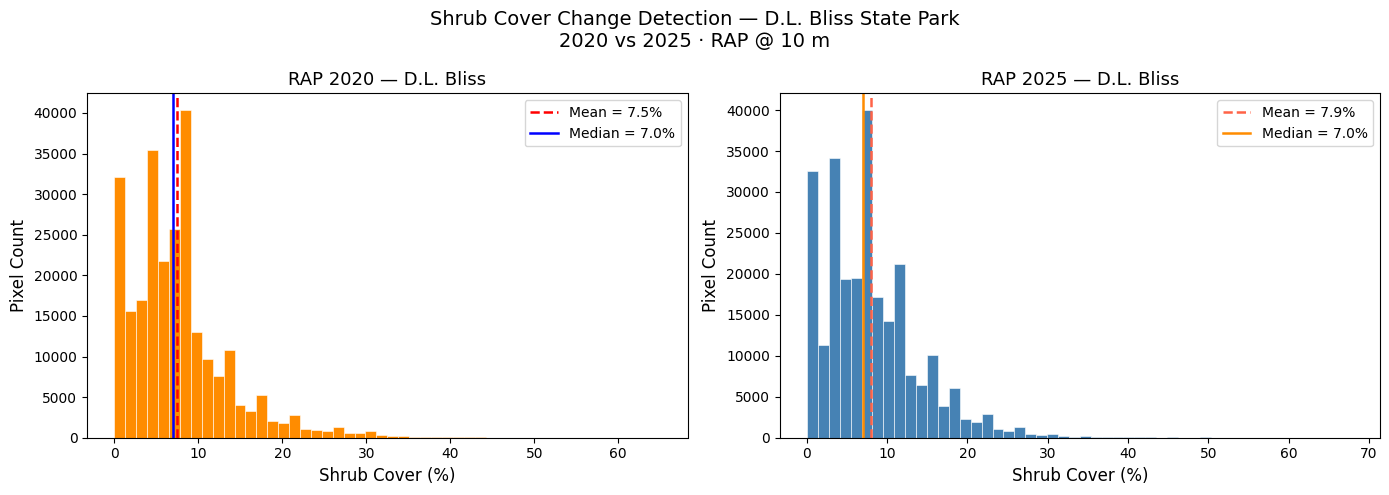

In [18]:
# ── BONUS: Temporal Change Detection — Shrub Cover 2020 vs 2025 ──────────────

# Get 2020 tile for the same location
images_2020 = RAP_veg_yearly_10m.filter(ee.Filter.eq('year', 2020))
bliss_tiles_2020 = images_2020.filterBounds(aoi)
bliss_img_2020 = ee.Image(
    bliss_tiles_2020
    .filter(ee.Filter.eq('x', 725000))
    .first()
)
shrub_2020 = bliss_img_2020.select('SHR').rename('shrub_cover')

# Extract 2020 array from same ROI
rect_2020 = shrub_2020.toFloat().sampleRectangle(region=roi_5km, defaultValue=-9999)
arr_2020  = np.array(rect_2020.get('shrub_cover').getInfo(), dtype=np.float32)
arr_2020[arr_2020 == -9999] = np.nan
valid_2020 = arr_2020[~np.isnan(arr_2020)]

# Stats 2020
mean_2020   = np.mean(valid_2020)
median_2020 = np.median(valid_2020)

print("=== Temporal Comparison — Shrub Cover D.L. Bliss ===")
print(f"  {'':10} {'2020':15} {'2025':15} {'Change':15}")
print(f"  {'Mean':10} {mean_2020:.2f}%         {mean_v:.2f}%         {mean_v - mean_2020:+.2f}%")
print(f"  {'Median':10} {median_2020:.2f}%         {median_v:.2f}%         {median_v - median_2020:+.2f}%")

# Side-by-side histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(valid_2020, bins=50, color='darkorange', edgecolor='white', linewidth=0.4)
axes[0].axvline(mean_2020, color='red', linestyle='--', linewidth=1.8, label=f'Mean = {mean_2020:.1f}%')
axes[0].axvline(median_2020, color='blue', linestyle='-', linewidth=1.8, label=f'Median = {median_2020:.1f}%')
axes[0].set_xlabel('Shrub Cover (%)', fontsize=12)
axes[0].set_ylabel('Pixel Count', fontsize=12)
axes[0].set_title('RAP 2020 — D.L. Bliss', fontsize=13)
axes[0].legend(fontsize=10)

axes[1].hist(valid, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(mean_v, color='tomato', linestyle='--', linewidth=1.8, label=f'Mean = {mean_v:.1f}%')
axes[1].axvline(median_v, color='darkorange', linestyle='-', linewidth=1.8, label=f'Median = {median_v:.1f}%')
axes[1].set_xlabel('Shrub Cover (%)', fontsize=12)
axes[1].set_ylabel('Pixel Count', fontsize=12)
axes[1].set_title('RAP 2025 — D.L. Bliss', fontsize=13)
axes[1].legend(fontsize=10)

plt.suptitle('Shrub Cover Change Detection — D.L. Bliss State Park\n2020 vs 2025 · RAP @ 10 m', fontsize=14)
plt.tight_layout()
plt.show()

## Interpretation — Temporal Change Detection


Comparing RAP shrub cover between 2020 (mean = 7.5%, median = 7.0%) and 
2025 (mean = 7.9%, median = 7.0%) reveals a slight increase of +0.4% in 
mean shrub cover at D.L. Bliss over 5 years. The stable median suggests 
the core distribution is unchanged, while the higher mean in 2025 reflects 
a modest expansion of high-shrub-cover pixels (10-20% range), visible in 
the right tail of the 2025 histogram.

This subtle increase could indicate gradual shrub encroachment into forest 
understory, post-disturbance recovery, or interannual variability in 
growing conditions. The stable median confirms no large-scale vegetation 
shift occurred between 2020 and 2025.

This temporal analysis demonstrates a key advantage of RAP's annual 
resolution — it enables multi-year monitoring of shrub dynamics at 
landscape scale, which will serve as a baseline validation layer in our 
Sprint 4 shrub detection pipeline.